# MASSIVE v2 MS/MS grouping

This notebook examines one informative file from [`novogaia/massive-v2`](https://huggingface.co/datasets/novogaia/massive-v2): `MSV000078577_t0.95_l0.80_grouped.hdf5` (6.4 MB). This is the stricter of the two available same-entity grouping settings. The smallest repository file contains only four ungrouped spectra, so it is not useful for studying grouping.

Only MS/MS rows (`MS level > 1`) are loaded. The notebook inspects the HDF5 schema, measures group coverage and sizes, verifies how local and global IDs relate, and visualizes one raw run and one example group.

In [1]:
from collections import Counter
import os
from pathlib import Path
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore", message="IProgress not found")
from huggingface_hub import hf_hub_download

REPO_ID = "novogaia/massive-v2"
REVISION = "10c48d8184119829c48651b8a40ea5e0b9015687"
FILENAME = "MSV000078577_t0.95_l0.80_grouped.hdf5"

path = Path(hf_hub_download(REPO_ID, FILENAME, repo_type="dataset", revision=REVISION))
print(f"File: {path}")
print(f"Size: {path.stat().st_size / 1e6:.2f} MB")

File: /home/wuhao/.cache/huggingface/hub/datasets--novogaia--massive-v2/snapshots/10c48d8184119829c48651b8a40ea5e0b9015687/MSV000078577_t0.95_l0.80_grouped.hdf5
Size: 6.41 MB


In [2]:
fields = (
    "file_id",
    "scan_number",
    "RT",
    "precursor_mz",
    "charge",
    "collision_energy",
    "precursor scan number",
    "group_id",
    "global_group_id",
)

with h5py.File(path) as f:
    schema = [
        (name, tuple(value.shape), str(value.dtype))
        for name, value in f.items()
        if isinstance(value, h5py.Dataset)
    ]
    levels = f["MS level"][:]
    msms = levels > 1
    data = {name: f[name][:][msms] for name in fields}
    spectra = f["spectrum"][:][msms]
    raw_file_names = np.char.decode(f["metadata/file_name"][:].astype("S"))

print("Top-level datasets:")
for name, shape, dtype in schema:
    print(f"  {name:28s} {str(shape):18s} {dtype}")
print(f"\nMS levels: {dict(zip(*np.unique(levels, return_counts=True), strict=True))}")
print(f"Loaded MS/MS spectra: {len(spectra):,} / {len(levels):,}")
assert spectra.shape == (len(data["group_id"]), 2, 128)

Top-level datasets:
  MS level                     (5356,)            int8
  RT                           (5356,)            float32
  acquisition_type             (5356,)            |S8
  activation_energy            (5356,)            float32
  charge                       (5356,)            int8
  collision_energy             (5356,)            float32
  dformat                      (5356,)            |S3
  file_id                      (5356,)            int32
  file_name                    (5356,)            object
  global_group_id              (5356,)            int64
  group_id                     (5356,)            int32
  instrument accuracy est.     (5356,)            float32
  massive_id                   (5356,)            object
  positive polarity            (5356,)            int8
  precursor intensity          (5356,)            float32
  precursor scan number        (5356,)            int32
  precursor target intensity   (5356,)            float32
  precursor_mz       

In [3]:
assigned = data["group_id"] >= 0
local_keys = list(
    zip(data["file_id"][assigned].tolist(), data["group_id"][assigned].tolist(), strict=True)
)
local_sizes = Counter(local_keys)
global_sizes = Counter(data["global_group_id"][assigned].tolist())
sizes = np.array(list(local_sizes.values()))
encoded_global_id = (
    data["file_id"][assigned].astype(np.int64) * 2**32
    + data["group_id"][assigned]
)

print(f"Assigned spectra:   {assigned.sum():,} ({assigned.mean():.1%})")
print(f"Unassigned (-1):    {(~assigned).sum():,} ({(~assigned).mean():.1%})")
print(f"Local groups:       {len(local_sizes):,}")
print(f"Global groups:      {len(global_sizes):,}")
print(f"Group size:         min={sizes.min()}, median={np.median(sizes):.0f}, mean={sizes.mean():.2f}, max={sizes.max()}")
print(f"Global ID formula:  file_id * 2**32 + group_id = {np.array_equal(data['global_group_id'][assigned], encoded_global_id)}")

assert np.array_equal(data["global_group_id"][assigned], encoded_global_id)
assert Counter(local_sizes.values()) == Counter(global_sizes.values())

Assigned spectra:   503 (9.4%)
Unassigned (-1):    4,853 (90.6%)
Local groups:       141
Global groups:      141
Group size:         min=2, median=2, mean=3.57, max=34
Global ID formula:  file_id * 2**32 + group_id = True


In [4]:
print(f"{'file_id':>7}  {'raw file':55s} {'MS/MS':>7} {'grouped':>8} {'groups':>7} {'max':>5}")
for file_id in np.unique(data["file_id"]):
    file_rows = data["file_id"] == file_id
    file_assigned = file_rows & assigned
    file_sizes = Counter(data["group_id"][file_assigned].tolist())
    print(
        f"{file_id:7d}  {raw_file_names[file_id]:55.55s} "
        f"{file_rows.sum():7d} {file_assigned.sum():8d} {len(file_sizes):7d} "
        f"{max(file_sizes.values()):5d}"
    )

file_id  raw file                                                  MS/MS  grouped  groups   max
      0  ccms_peak_15998_nBuOH_FT_test01                            4212      348     123     7
      1  ccms_peak_daptomycin_mix_data_dependent                     209       40       5    15
      2  ccms_peak_roseosporus_BuOH_extract_datadependent_FTMS1I     265       32       4    17
      3  ccms_peak_roseosporus_BuOH_extracts-data_dependent          430       76       8    34
      4  ccms_peak_roseosporus_extracts-data_dependent               240        7       1     7


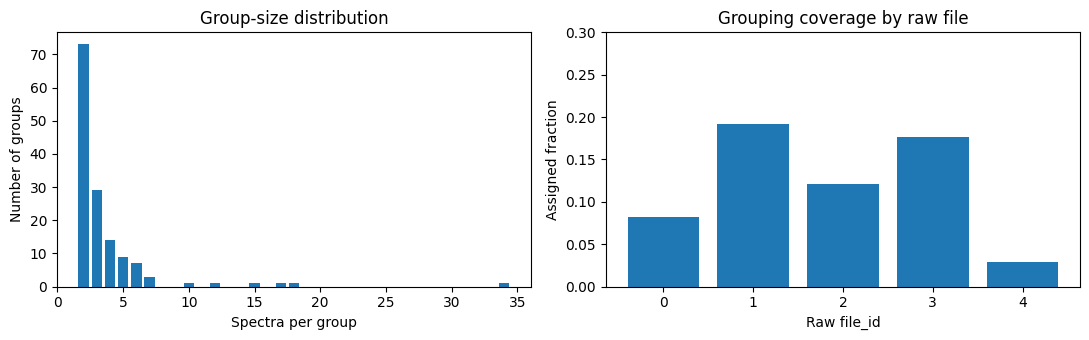

In [5]:
size_counts = Counter(sizes.tolist())
file_ids = np.unique(data["file_id"])
grouped_fractions = [
    assigned[data["file_id"] == file_id].mean() for file_id in file_ids
]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(size_counts.keys(), size_counts.values())
axes[0].set(xlabel="Spectra per group", ylabel="Number of groups", title="Group-size distribution")
axes[1].bar(file_ids.astype(str), grouped_fractions)
axes[1].set(xlabel="Raw file_id", ylabel="Assigned fraction", title="Grouping coverage by raw file", ylim=(0, 0.3))
plt.tight_layout()
plt.show()

In [6]:
largest = local_sizes.most_common(10)
print(f"{'file':>4} {'group':>5} {'n':>4} {'RT span (s)':>13} {'precursor m/z range':>24} {'precursor scans':>15}")
for (file_id, group_id), n in largest:
    mask = (data["file_id"] == file_id) & (data["group_id"] == group_id)
    rt = data["RT"][mask]
    mz = data["precursor_mz"][mask]
    precursor_scans = np.unique(data["precursor scan number"][mask]).size
    print(
        f"{file_id:4d} {group_id:5d} {n:4d} {np.ptp(rt):13.1f} "
        f"{mz.min():9.2f}–{mz.max():9.2f} {precursor_scans:15d}"
    )

file group    n   RT span (s)      precursor m/z range precursor scans
   3     0   34         771.0    577.79–  1178.65              21
   3     2   18         368.8    580.82–  1178.64              11
   2     0   17         380.8    417.28–  1192.65              13
   1     0   15          61.9    423.70–  1662.79              10
   1     2   12         194.0    423.70–  1648.78               5
   3     1   10         185.6    577.79–  1178.64               5
   0    19    7         175.4    417.25–   570.30               7
   2     3    7          45.6    414.17–   874.48               6
   4     0    7          26.8    423.70–  1174.63               5
   0    80    6          69.1    441.22–   659.37               5


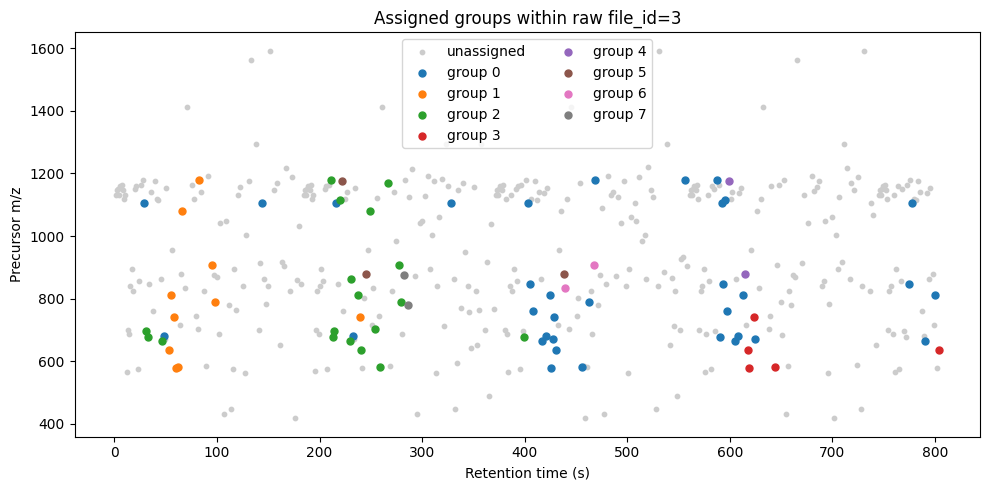

In [7]:
example_file_id = 3
file_rows = data["file_id"] == example_file_id
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    data["RT"][file_rows & ~assigned],
    data["precursor_mz"][file_rows & ~assigned],
    s=10,
    c="0.8",
    label="unassigned",
)
for group_id in np.unique(data["group_id"][file_rows & assigned]):
    mask = file_rows & (data["group_id"] == group_id)
    ax.scatter(data["RT"][mask], data["precursor_mz"][mask], s=25, label=f"group {group_id}")
ax.set(
    xlabel="Retention time (s)",
    ylabel="Precursor m/z",
    title=f"Assigned groups within raw file_id={example_file_id}",
)
ax.legend(ncols=2)
plt.tight_layout()
plt.show()

Same-entity ensemble: file_id=4, group_id=0, 7 spectra, RT span=26.8s, precursor m/z=423.70–1174.63


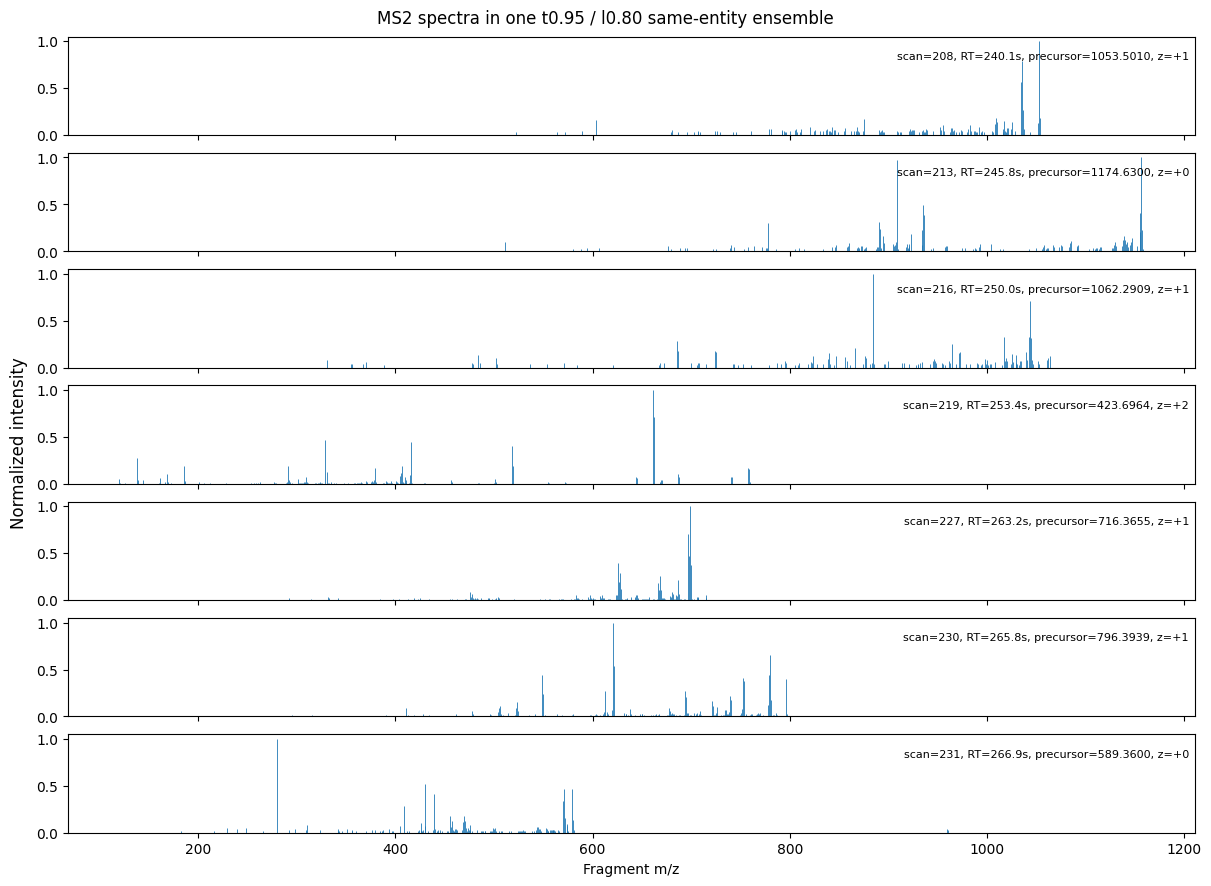

In [8]:
# Compact strict ensemble with seven distinct precursor ions.
example_file_id = 4
example_group_id = 0
example_global_group_id = example_file_id * 2**32 + example_group_id
entity_rows = np.flatnonzero(data["global_group_id"] == example_global_group_id)
entity_rows = entity_rows[np.argsort(data["RT"][entity_rows])]
assert len(entity_rows) == 7

print(
    f"Same-entity ensemble: file_id={example_file_id}, group_id={example_group_id}, "
    f"{len(entity_rows)} spectra, RT span={np.ptp(data['RT'][entity_rows]):.1f}s, "
    f"precursor m/z={data['precursor_mz'][entity_rows].min():.2f}–"
    f"{data['precursor_mz'][entity_rows].max():.2f}"
)
fig, axes = plt.subplots(
    len(entity_rows), 1, sharex=True, figsize=(12, 1.25 * len(entity_rows)), layout="constrained"
)
for ax, row in zip(axes, entity_rows, strict=True):
    mz, intensity = spectra[row]
    valid = intensity > 0
    ax.vlines(mz[valid], 0, intensity[valid] / intensity[valid].max(), linewidth=0.6)
    ax.set_ylim(0, 1.05)
    ax.text(
        0.995,
        0.85,
        f"scan={data['scan_number'][row]}, RT={data['RT'][row]:.1f}s, "
        f"precursor={data['precursor_mz'][row]:.4f}, z={data['charge'][row]:+d}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
    )
axes[-1].set_xlabel("Fragment m/z")
fig.supylabel("Normalized intensity")
fig.suptitle("MS2 spectra in one t0.95 / l0.80 same-entity ensemble")
plt.show()

## Findings

- This example contains **5,356 spectra, all MS2**, across five raw LC-MS files.
- **503 spectra (9.4%)** are assigned to **141 groups**; the remaining 4,853 use the sentinel `group_id = global_group_id = -1`.
- Assigned group sizes range from 2 to 34 spectra (median 2, mean 3.57).
- `group_id` is local to a raw `file_id` and is reused between raw files. In this file, `global_group_id = file_id * 2**32 + group_id`, so `global_group_id` is the safe grouping key after concatenating raw files.
- Groups are not simply identical-precursor buckets: the largest groups span multiple precursor m/z values, precursor scans, and retention times.
- The final figure compares all seven spectra in one strict same-entity ensemble. It intentionally includes different precursor m/z and charge values because an Ensemble represents a chemical entity rather than one precursor ion.

The dataset repository has no dataset card or HDF5 attributes defining the grouping algorithm. These results therefore establish the stored grouping semantics and empirical composition, but not how the producer generated the assignments.